Dataset Shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

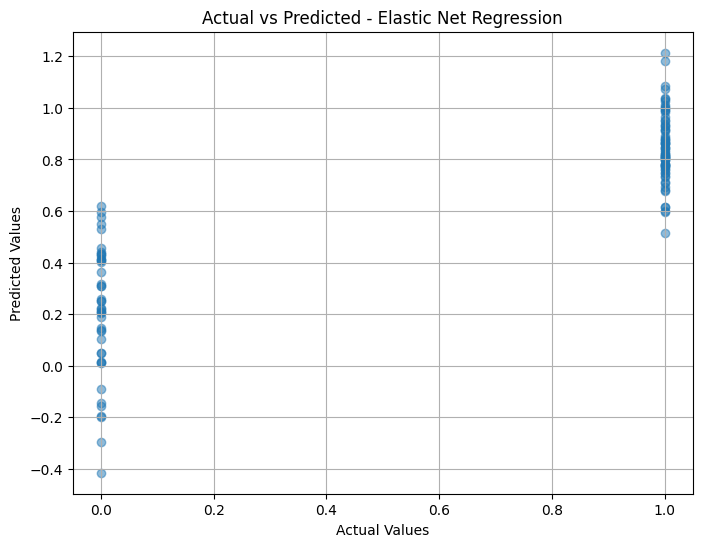

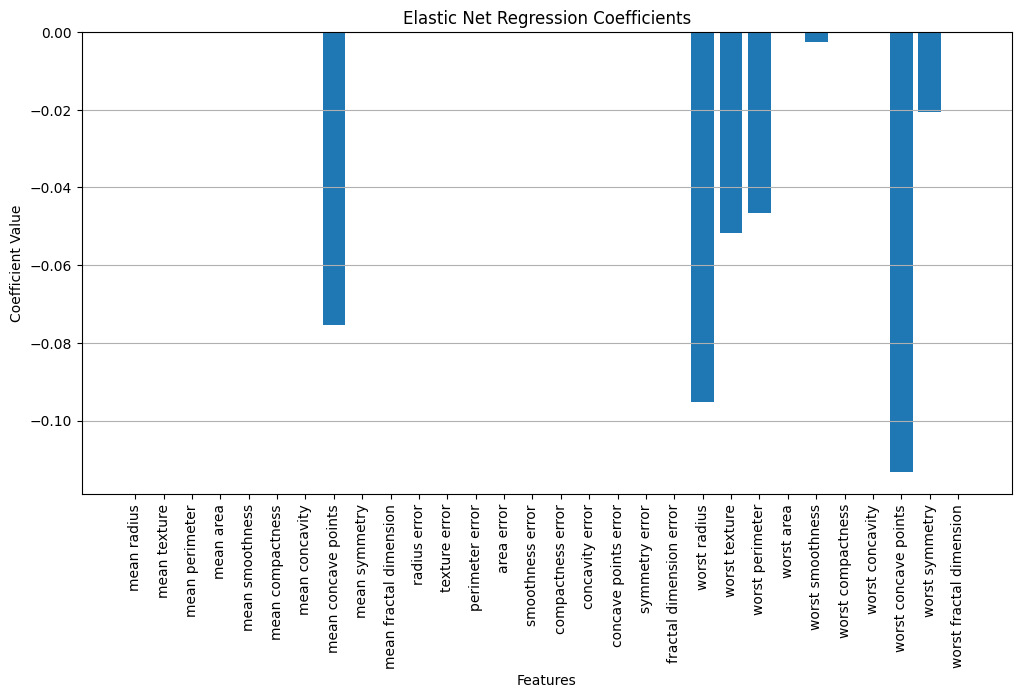

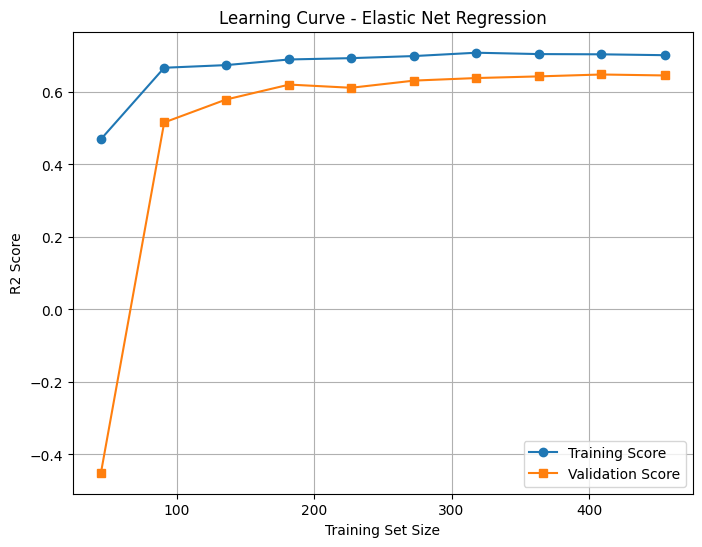


Alpha Comparison
----------------------------------------------------------------------
Alpha     Train R2       Test R2        Remarks
0.001     0.7761         0.7466         Balanced
0.01      0.7491         0.7453         Balanced
0.1       0.6975         0.7189         Balanced
1         0.0000         -0.0001        Underfitting
10        0.0000         -0.0001        Underfitting

L1 Ratio Comparison
----------------------------------------------------------------------
L1 Ratio  Train R2       Test R2        Remarks
0.2       0.7186         0.7303         Balanced
0.4       0.7059         0.7241         Balanced
0.6       0.6883         0.7133         Balanced
0.8       0.6674         0.6992         Balanced
1.0       0.6450         0.6797         Balanced


In [1]:
# Programming Assignment 34
# Elastic Net Regression on Breast Cancer Dataset
# considering bias, variance, overfitting and underfitting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())
print("\nTarget values:")
print(y.head())

# --------------------------------------------------
# 2. Split dataset into training and testing sets
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# 3. Standardize features
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 4. Train Elastic Net model
#    alpha controls overall regularization strength
#    l1_ratio controls mix of Lasso and Ridge
# --------------------------------------------------
alpha_value = 0.1
l1_ratio_value = 0.5

elastic_model = ElasticNet(
    alpha=alpha_value,
    l1_ratio=l1_ratio_value,
    max_iter=10000,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 5. Predictions
# --------------------------------------------------
y_train_pred = elastic_model.predict(X_train_scaled)
y_test_pred = elastic_model.predict(X_test_scaled)

# --------------------------------------------------
# 6. Evaluation
# --------------------------------------------------
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nElastic Net Regression Results")
print("-" * 50)
print("Alpha     :", alpha_value)
print("L1 Ratio  :", l1_ratio_value)
print("Training RMSE :", round(train_rmse, 4))
print("Testing RMSE  :", round(test_rmse, 4))
print("Training R2   :", round(train_r2, 4))
print("Testing R2    :", round(test_r2, 4))

# --------------------------------------------------
# 7. Bias, Variance, Overfitting, Underfitting analysis
# --------------------------------------------------
print("\nAnalysis")
print("-" * 50)

if train_r2 < 0.6 and test_r2 < 0.6:
    print("Model shows HIGH BIAS -> likely UNDERFITTING")
elif train_r2 > 0.9 and (train_r2 - test_r2) > 0.1:
    print("Model shows HIGH VARIANCE -> likely OVERFITTING")
else:
    print("Model has a reasonable bias-variance balance")

print("Train-Test R2 Difference:", round(abs(train_r2 - test_r2), 4))

# --------------------------------------------------
# 8. Coefficients
# --------------------------------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": elastic_model.coef_
})

print("\nFeature Coefficients:")
print(coef_df)

# --------------------------------------------------
# 9. Plot Actual vs Predicted
# --------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Elastic Net Regression")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 10. Plot coefficients
# --------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=90)
plt.title("Elastic Net Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.grid(axis='y')
plt.show()

# --------------------------------------------------
# 11. Learning curve for bias and variance understanding
# --------------------------------------------------
X_scaled_full = StandardScaler().fit_transform(X)

train_sizes, train_scores, val_scores = learning_curve(
    ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio_value, max_iter=10000, random_state=42),
    X_scaled_full,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_scores_mean, marker='s', label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - Elastic Net Regression")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 12. Underfitting and overfitting comparison with different alpha values
# --------------------------------------------------
alpha_list = [0.001, 0.01, 0.1, 1, 10]

print("\nAlpha Comparison")
print("-" * 70)
print(f"{'Alpha':<10}{'Train R2':<15}{'Test R2':<15}{'Remarks'}")

for a in alpha_list:
    model = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_r2 = r2_score(y_train, train_pred)
    te_r2 = r2_score(y_test, test_pred)

    if tr_r2 < 0.6 and te_r2 < 0.6:
        remark = "Underfitting"
    elif tr_r2 - te_r2 > 0.1:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{a:<10}{tr_r2:<15.4f}{te_r2:<15.4f}{remark}")

# --------------------------------------------------
# 13. Underfitting and overfitting comparison with different l1_ratio values
# --------------------------------------------------
l1_ratio_list = [0.2, 0.4, 0.6, 0.8, 1.0]

print("\nL1 Ratio Comparison")
print("-" * 70)
print(f"{'L1 Ratio':<10}{'Train R2':<15}{'Test R2':<15}{'Remarks'}")

for l1 in l1_ratio_list:
    model = ElasticNet(alpha=0.1, l1_ratio=l1, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_r2 = r2_score(y_train, train_pred)
    te_r2 = r2_score(y_test, test_pred)

    if tr_r2 < 0.6 and te_r2 < 0.6:
        remark = "Underfitting"
    elif tr_r2 - te_r2 > 0.1:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{l1:<10}{tr_r2:<15.4f}{te_r2:<15.4f}{remark}")